#### Import required packages

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

#### Import sample data and drop uneccessary columns

In [2]:
data_for_model = pd.read_pickle("data/abc_classification_modelling.p")
data_for_model.drop("customer_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['signup_flag', 'distance_from_store', 'gender', 'credit_score',
       'total_sales', 'total_items', 'transaction_count', 'product_area_count',
       'average_basket_value'],
      dtype='object')


#### Shuffle data

In [3]:
data_for_model = shuffle(data_for_model, random_state = 42)
print(data_for_model)

     signup_flag  distance_from_store gender  credit_score  total_sales  \
714            0                 1.64      M          0.58        27.81   
605            0                 0.88      M          0.63        26.62   
120            0                 0.56      M          0.62       886.78   
208            0                 0.11      M          0.58      1256.19   
380            0                 1.32      M          0.36       739.67   
..           ...                  ...    ...           ...          ...   
71             0                 0.07      M          0.57       746.15   
106            0                 1.96      F          0.60       881.49   
270            0                 1.59      M          0.50       319.37   
435            0                 0.71      F          0.54       273.94   
102            0                 2.60      F          0.48       523.41   

     total_items  transaction_count  product_area_count  average_basket_value  
714            6   

#### Class Balance

In [4]:
data_for_model["signup_flag"].value_counts(normalize = True)

signup_flag
0    0.689535
1    0.310465
Name: proportion, dtype: float64

#### Dealing with missing values

In [5]:
data_for_model.isna().sum()
data_for_model.dropna(how = "any", inplace = True)

#### Split Input variables and Output variables

In [6]:
X = data_for_model.drop(["signup_flag"], axis = 1)
y = data_for_model["signup_flag"]

#### Split out training and test sets

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

#### Dealing with categorical variables

In [8]:
categorical_vars = ["gender"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop = True), X_test_encoded.reset_index(drop = True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [9]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0                   1.22          0.60       636.51          123   
1                   0.86          0.56      1141.28          112   
2                   1.23          0.79      1207.42          210   
3                   1.04          0.40        78.18           11   
4                   0.07          0.62       740.51           94   
..                   ...           ...          ...          ...   
672                 0.95          0.45       714.06          135   
673                 3.85          0.58      1357.93          210   
674                 1.51          0.67       958.23          160   
675                 4.49          0.43      1531.61          135   
676                 0.62          0.56       368.56           58   

     transaction_count  product_area_count  average_basket_value  gender_M  
0                   22                   5             28.932273       0.0  
1                   21       

#### Model Training

In [10]:
clf = RandomForestClassifier(random_state = 42, n_estimators = 500, max_features = 5)
clf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Assessment

In [11]:
y_pred_class = clf.predict(X_test)
print(y_pred_class)

[1 1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1
 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 1 1 0 1 1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 0 0
 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0]


In [12]:
y_pred_prob = clf.predict_proba(X_test)[:,1]
print(y_pred_prob)

[0.92  1.    0.996 0.022 0.048 1.    0.782 0.022 0.966 0.078 0.11  0.
 0.088 0.128 0.006 0.    0.658 0.906 0.974 0.838 0.028 0.016 0.96  0.
 0.14  0.008 0.002 0.    0.946 0.764 0.01  0.    0.032 0.    0.512 0.028
 0.872 0.636 0.008 0.156 0.03  0.002 0.006 0.    0.014 0.078 0.86  0.002
 1.    0.016 0.    0.    0.    0.    0.002 0.838 0.004 0.012 0.996 0.926
 0.    0.    0.522 0.93  0.012 0.642 0.048 0.282 0.05  0.    0.032 0.016
 0.    0.002 0.038 0.    0.936 0.012 0.034 0.    0.01  0.486 0.006 0.018
 0.944 0.556 0.006 0.948 0.882 0.956 0.044 1.    0.666 0.022 0.018 0.002
 0.096 1.    0.914 0.992 0.    0.102 0.038 0.02  0.344 0.012 0.068 0.014
 0.    0.01  0.012 0.168 0.33  0.764 0.    0.01  0.942 0.412 0.016 1.
 0.052 0.002 0.006 0.856 0.336 0.    0.092 0.022 0.2   0.    0.19  0.
 0.024 0.354 0.002 0.004 0.664 0.734 0.656 0.026 0.936 0.    1.    0.006
 0.94  0.01  0.    0.    0.136 0.008 0.968 0.762 0.022 0.384 0.638 1.
 0.574 0.146 0.998 0.02  0.026 0.952 0.016 0.874 0.002 0.    0.   

#### Confusion matrix

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
print(conf_matrix)

[[112   6]
 [  5  47]]


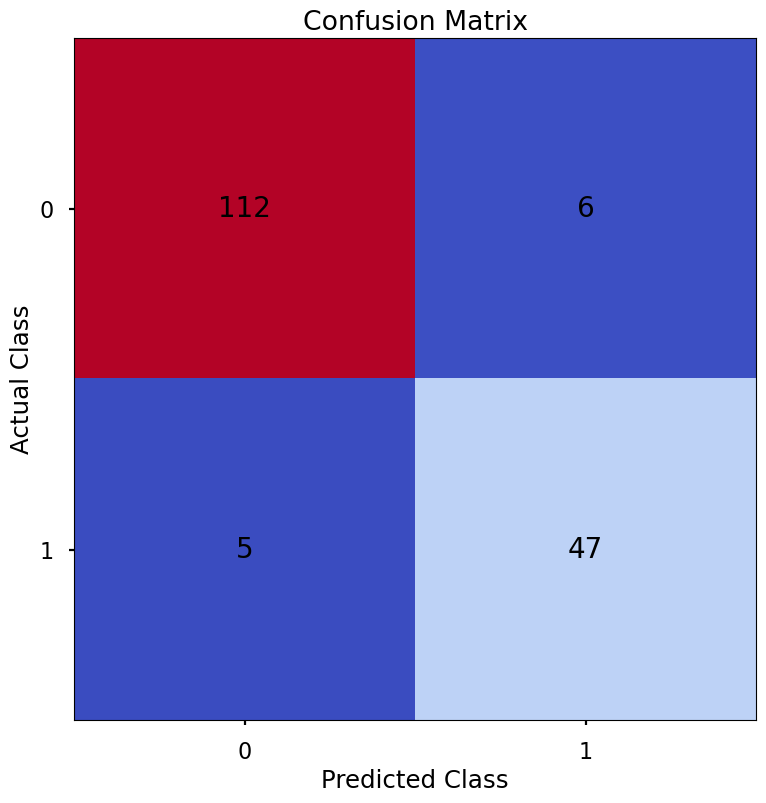

In [14]:
plt.style.use("seaborn-v0_8-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)
plt.show()

 #### Accuracy (the number of correct classification out of all attempted classifications)

In [15]:
accuracy_score(y_test, y_pred_class)

0.9352941176470588

#### Precision (of all observations that were predicted as positive, how many were actually positive)

In [16]:
precision_score(y_test, y_pred_class)

0.8867924528301887

#### Recall (of all positive observations, how many did we predict as positive)

In [17]:
recall_score(y_test, y_pred_class)

0.9038461538461539

#### F1-Score (the harmonic mean of precision and recall)

In [18]:
f1_score(y_test, y_pred_class)

0.8952380952380953

#### Feature importance

In [19]:
feature_importance = pd.DataFrame(clf.feature_importances_)
feature_names = pd.DataFrame(X.columns)
feature_importance_summary = pd.concat([feature_names,feature_importance], axis = 1)
feature_importance_summary.columns = ["input_variable","feature_importance"]
feature_importance_summary.sort_values(by = "feature_importance", inplace = True)
print(feature_importance_summary)

         input_variable  feature_importance
1                gender            0.024698
3           total_sales            0.039331
7  average_basket_value            0.051438
4           total_items            0.057100
6    product_area_count            0.094937
2          credit_score            0.111444
5     transaction_count            0.153123
0   distance_from_store            0.467928


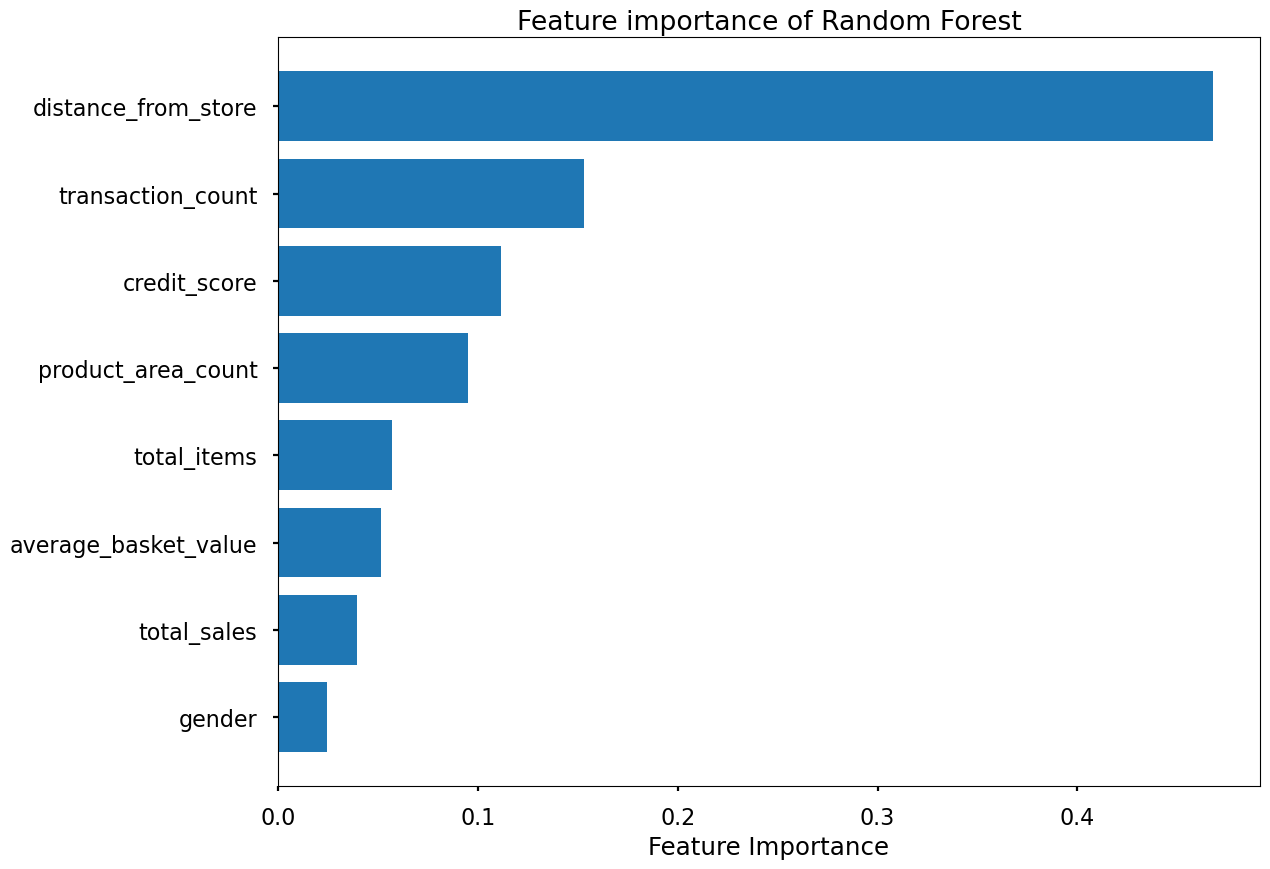

In [20]:
plt.barh(feature_importance_summary["input_variable"],feature_importance_summary["feature_importance"])
plt.title("Feature importance of Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

#### Permutation importance

In [21]:
result = permutation_importance(clf, X_test, y_test, n_repeats = 10, random_state = 42)

In [22]:
permutation_importance = pd.DataFrame(result["importances_mean"])
feature_names = pd.DataFrame(X.columns)
permutation_importance_summary = pd.concat([feature_names,permutation_importance], axis = 1)
permutation_importance_summary.columns = ["input_variable","permutation_importance"]
permutation_importance_summary.sort_values(by = "permutation_importance", inplace = True)

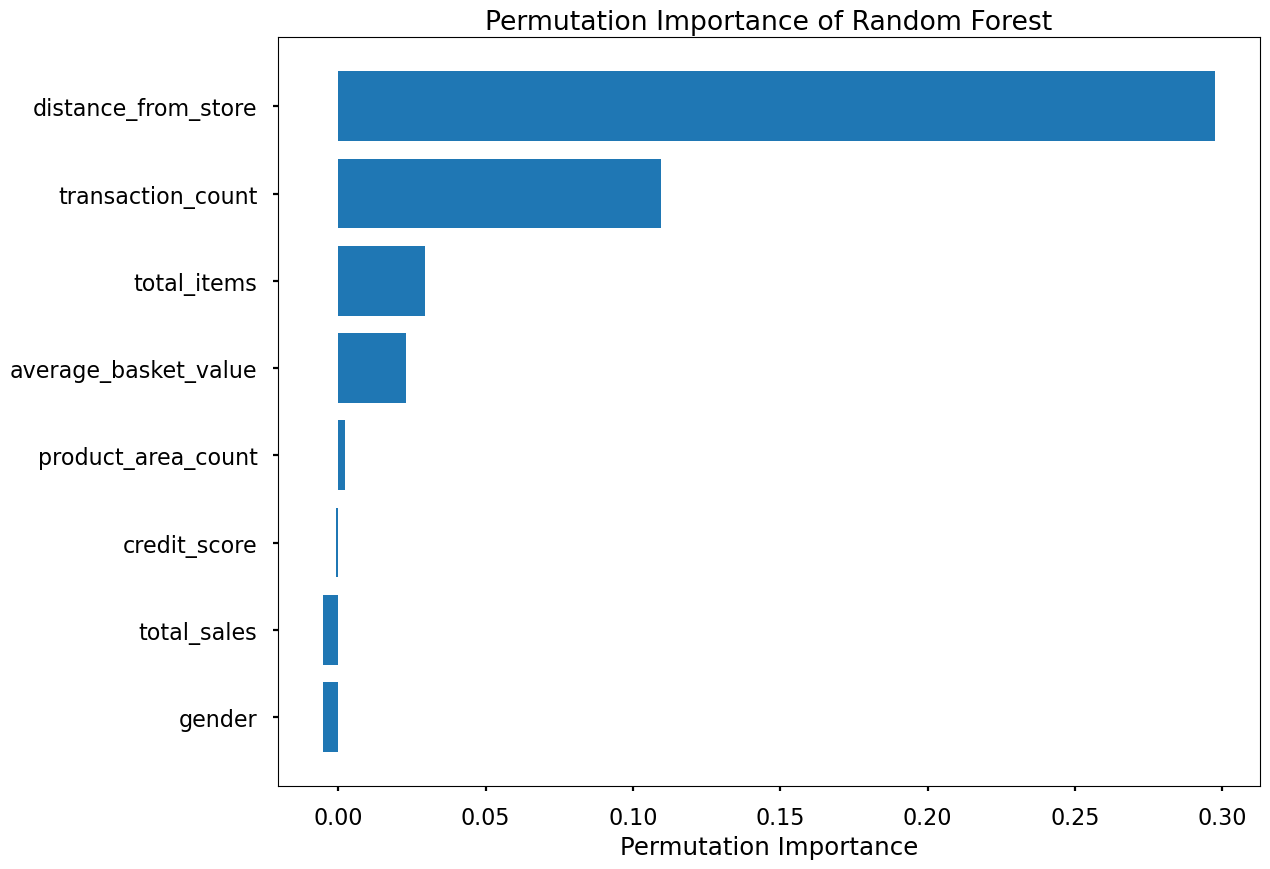

In [23]:
plt.barh(permutation_importance_summary["input_variable"], permutation_importance_summary["permutation_importance"])
plt.title("Permutation Importance of Random Forest")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()